#***GEREKLİ KÜTÜPHANELERİN YÜKLENMESİ***

In [ ]:
import numpy as np
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


##Veri Setini Yükleme

In [ ]:
# Veri yolu
import os
# os.getcwd() -> notebook hangi klasorden acilirsa orasi baz alinir
base_dir  = os.path.join(os.getcwd(), "Snake Images")
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")
print("Train:", train_dir)
print("Test: ", test_dir)


##Model Parametreleri ve Eğitim Ayarları

In [ ]:
# Model parametreleri
input_shape = (224, 224, 3)  # Görüntü boyutları
num_classes = 1  # Binary sınıflandırma (Venomous/Non-Venomous)
batch_size = 32

#Veri Artırma ve Veri Yükleme (Data Augmentation & Generators)

In [ ]:
# Eğitim için veri artırma (Data Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,                # Normalizasyon [0, 1]
    rotation_range=20,             # Görüntü döndürme (derece cinsinden)
    width_shift_range=0.2,         # Görüntü genişliğini kaydırma
    height_shift_range=0.2,        # Görüntü yüksekliğini kaydırma
    shear_range=0.2,               # Kesme işlemi
    zoom_range=0.2,                # Yakınlaştırma
    horizontal_flip=True,          # Yatay çevirme
    fill_mode='nearest'            # Doldurma modu (boşlukları doldur)
)

test_datagen = ImageDataGenerator(rescale=1.0/255)  # Sadece normalize

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',  # Binary sınıflandırma için
    classes=['Non Venomous', 'Venomous']  # Klasörleri manuel olarak belirtin
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',  # Binary sınıflandırma için
    classes=['Non Venomous', 'Venomous']  # Klasörleri manuel olarak belirtin
)

##Eğitim ve Test Verisi Kontrolleri

In [ ]:
# Eğitim etiketlerini kontrol et
print("Eğitim Etiketleri:")
print(np.unique(train_generator.classes))

# Doğrulama etiketlerini kontrol et
print("Doğrulama Etiketleri:")
print(np.unique(test_generator.classes))

# Eğitim setindeki sınıf dağılımı
unique, counts = np.unique(train_generator.classes, return_counts=True)
print("Eğitim Sınıf Dağılımı:")
print(dict(zip(unique, counts)))

# Doğrulama setindeki sınıf dağılımı
unique, counts = np.unique(test_generator.classes, return_counts=True)
print("Doğrulama Sınıf Dağılımı:")
print(dict(zip(unique, counts)))

print("Sınıf İsimleri (Eğitim):")
print(train_generator.class_indices)




##Veri Görselleştirme - Eğitim Verisi Örnekleri

In [ ]:
# Eğitim setinden birkaç örnek al
x_batch, y_batch = next(train_generator)

# İlk 5 görüntüyü ve etiketlerini göster
for i in range(5):
    plt.imshow(x_batch[i])
    plt.title(f"Etiket: {y_batch[i]}")
    plt.axis('off')
    plt.show()

##Model Oluşturma - ResNet50 Transfer Learning

In [ ]:
from tensorflow.keras.applications import ResNet50
# ResNet50 Modeli Oluşturma
def create_resnet50_model(input_shape, num_classes):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Taban katmanları dondur
    for layer in base_model.layers:
        layer.trainable = False

    # Yeni katmanlar ekle
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Modeli oluştur
resnet_model = create_resnet50_model(input_shape=input_shape, num_classes=num_classes)


###Model Derleme ve Eğitim - ResNet50

In [ ]:
# Modeli derle
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks tanımlama
lr_scheduler_res = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)
early_stop_res = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Sınıf ağırlıkları
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

# Modeli eğitme
history_res = resnet_model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=[lr_scheduler_res, early_stop_res]
)

###Model Kaydetme ve Değerlendirme - ResNet50

In [ ]:
# Modeli kaydet
resnet_model.save("resnet50_snake_model.keras")

# Modeli değerlendirme
test_loss_res, test_accuracy_res = resnet_model.evaluate(test_generator)
print(f"Test Loss: {test_loss_res}, Test Accuracy: {test_accuracy_res}")

###Confusion Matrix - ResNet50

In [ ]:
# Confusion Matrix için tahminler
test_labels = test_generator.classes  # Test verisinin gerçek etiketleri
class_names = list(test_generator.class_indices.keys())  # Sınıf isimleri

resnet_predictions = resnet_model.predict(test_generator)
resnet_predicted_labels = np.round(resnet_predictions).astype(int)  # Tahminler binary olduğu için yuvarlama

# Confusion Matrix Çizimi
cm = confusion_matrix(test_labels, resnet_predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("ResNet50 - Confusion Matrix")
plt.show()

###Eğitim Süreci Grafikleri - ResNet50

In [ ]:
train_acc_res = history_res.history['accuracy']
val_acc_res = history_res.history['val_accuracy']
train_loss_res = history_res.history['loss']
val_loss_res = history_res.history['val_loss']

epochs_res = range(1, len(train_acc_res) + 1)

plt.figure(figsize=(14, 6))

# Doğruluk grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_res, train_acc_res, label='Eğitim Doğruluğu')
plt.plot(epochs_res, val_acc_res, label='Doğrulama Doğruluğu')
plt.title('Doğruluk Grafiği')
plt.xlabel('Epochs')
plt.ylabel('Doğruluk')
plt.legend()

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_res, train_loss_res, label='Eğitim Kaybı')
plt.plot(epochs_res, val_loss_res, label='Doğrulama Kaybı')
plt.title('Kayıp Grafiği')
plt.xlabel('Epochs')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()

##Transfer Learning - VGG16


In [ ]:
# Transfer Learning Modeli
def create_transfer_learning_model(input_shape, num_classes):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    # Yeni katmanlar ekleyin
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    predictions = Dense(num_classes, activation='sigmoid' if num_classes == 1 else 'softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Önceden eğitilmiş katmanları dondur
    for layer in base_model.layers:
        layer.trainable = False

    return model


###Model Derleme ve Eğitim - VGG16

In [ ]:
# Sınıf ağırlıklarını hesaplama
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# Sınıf ağırlıklarını dict formatına dönüştürme
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

# ReduceLROnPlateau tanımlama
lr_scheduler_vgg = ReduceLROnPlateau(
    monitor='val_loss',   # Hangi metriği takip edecek
    factor=0.5,           # Öğrenme hızını yarıya indir
    patience=3,           # Kaç epoch bekleyecek
    min_lr=1e-6           # Minimum öğrenme hızı
)

early_stop_vgg = EarlyStopping(
    monitor='val_loss',
    patience=2,  # Bekleme süresini 10 epoch'a çıkardık
    min_delta=0.001,
    restore_best_weights=True
)


In [ ]:
# Modeli oluştur
cnn_model = create_transfer_learning_model(input_shape, num_classes)

# İlk birkaç epoch'tan sonra dondurmayı kaldırın
for layer in cnn_model.layers[:15]:  # İlk 15 katmanı eğitime aç
    layer.trainable = True

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Daha düşük öğrenme hızı
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model özeti
cnn_model.summary()

# Model eğitimi
history_vgg = cnn_model.fit(
    train_generator,
    epochs=50,  # Fine-tuning için birkaç epoch (ör. 10-20) ekleyebilirsiniz
    validation_data=test_generator,
    class_weight=class_weights,  # Sınıf ağırlıkları
    callbacks=[lr_scheduler_vgg,early_stop_vgg]  # Öğrenme oranını dinamik olarak ayarlamak için
)


### Model Değerlendirme ve Confusion Matrix - VGG16

In [ ]:
# Test verileri ile değerlendirme
test_loss_vgg, test_accuracy_vgg = cnn_model.evaluate(test_generator)
print(f"Test Loss: {test_loss_vgg}, Test Accuracy: {test_accuracy_vgg}")

# Confusion Matrix için tahminler
test_labels = test_generator.classes  # Test verisinin gerçek etiketleri
class_names = list(test_generator.class_indices.keys())  # Sınıf isimleri

vgg16_predictions = cnn_model.predict(test_generator)
vgg16_predicted_labels = np.round(vgg16_predictions).astype(int)  # Binary sınıflandırma için yuvarlama

# Confusion Matrix Çizimi
cm_vgg = confusion_matrix(test_labels, vgg16_predicted_labels)
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=class_names)
disp_vgg.plot(cmap=plt.cm.Blues)
plt.title("VGG16 - Confusion Matrix")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Eğitim ve doğrulama metriklerini alma
train_accuracy_vgg = history_vgg.history['accuracy']
val_accuracy_vgg = history_vgg.history['val_accuracy']
train_loss_vgg  = history_vgg.history['loss']
val_loss_vgg = history_vgg.history['val_loss']

# Epoch sayısını belirleme
epochs_vgg = range(1, len(train_accuracy_vgg) + 1)

# 1. Doğruluk grafiği
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_vgg, train_accuracy_vgg, label='Eğitim Doğruluğu')
plt.plot(epochs_vgg, val_accuracy_vgg, label='Doğrulama Doğruluğu')
plt.title('Doğruluk Grafiği')
plt.xlabel('Epochs')
plt.ylabel('Doğruluk')
plt.legend()

# 2. Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_vgg, train_loss_vgg, label='Eğitim Kaybı')
plt.plot(epochs_vgg, val_loss_vgg, label='Doğrulama Kaybı')
plt.title('Kayıp Grafiği')
plt.xlabel('Epochs')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()


# MobilNetV2 modeli


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
import tensorflow as tf

# MobilNetV2 modeli
def create_mobilenetv2_model(input_shape, num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Taban katmanlarını dondur
    for layer in base_model.layers:
        layer.trainable = False

    # Yeni katmanlar ekleyin
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Havuzlama katmanı
    x = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = Dropout(0.4)(x)
    predictions = Dense(1, activation='sigmoid')(x)  # Binary sınıflandırma

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Modeli oluştur
mobilenet_model = create_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=1)

# Modeli derle
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:

# Model özeti
mobilenet_model.summary()


In [ ]:
# Model özeti
mobilenet_model.summary()

# Sınıf ağırlıklarını hesaplama
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

# Callbacks tanımlama
lr_scheduler_mobile = ReduceLROnPlateau(
    monitor='val_loss',   # Hangi metriği takip edecek
    factor=0.5,           # Öğrenme hızını yarıya indir
    patience=3,           # Kaç epoch bekleyecek
    min_lr=1e-6           # Minimum öğrenme hızı
)

early_stop_mobile = EarlyStopping(
    monitor='val_loss',
    patience=7,  # Bekleme süresini 10 epoch'a çıkardık
    min_delta=0.001,
    restore_best_weights=True
)




# Model eğitimi
history_mobile = mobilenet_model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=[lr_scheduler_mobile, early_stop_mobile]  # ReduceLROnPlateau ve EarlyStopping
)



In [ ]:
# Modeli kaydetme
mobilenet_model.save("snake_classification_model.keras")


In [ ]:
# Test verileri ile değerlendirme
test_loss, test_accuracy = mobilenet_model.evaluate(test_generator)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")


In [ ]:
# Confusion Matrix için tahminler
test_labels = test_generator.classes  # Test verisinin gerçek etiketleri
class_names = list(test_generator.class_indices.keys())  # Sınıf isimleri

mobilenet_predictions = mobilenet_model.predict(test_generator)
mobilenet_predicted_labels = np.round(mobilenet_predictions).astype(int)  # Binary sınıflandırma için yuvarlama

# Confusion Matrix Çizimi
cm_mobile = confusion_matrix(test_labels, mobilenet_predicted_labels)
disp_mobile = ConfusionMatrixDisplay(confusion_matrix=cm_mobile, display_labels=class_names)
disp_mobile.plot(cmap=plt.cm.Blues)
plt.title("MobileNetV2 - Confusion Matrix")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Eğitim ve doğrulama metriklerini alma
train_acc_mobile = history_mobile.history['accuracy']
val_acc_mobile = history_mobile.history['val_accuracy']
train_loss_mobile = history_mobile.history['loss']
val_loss_mobile = history_mobile.history['val_loss']

# Epoch sayısını belirleme
epochs_mobile = range(1, len(train_acc_mobile) + 1)

# 1. Doğruluk grafiği
plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_mobile, train_acc_mobile, label='Eğitim Doğruluğu')
plt.plot(epochs_mobile, val_acc_mobile, label='Doğrulama Doğruluğu')
plt.title('Doğruluk Grafiği')
plt.xlabel('Epochs')
plt.ylabel('Doğruluk')
plt.legend()

# 2. Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_mobile, train_loss_mobile, label='Eğitim Kaybı')
plt.plot(epochs_mobile, val_loss_mobile, label='Doğrulama Kaybı')
plt.title('Kayıp Grafiği')
plt.xlabel('Epochs')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()


## Model Karşılaştırması (VGG16, MobileNetV2, ResNet50)

In [ ]:
# Epoch sayısı
epochs_vgg  = range(1, len(train_accuracy_vgg) + 1)
epochs_mobile = range(1, len(train_acc_mobile) + 1)
epochs_res = range(1, len(train_acc_res) + 1)

# Grafik çizimi
plt.figure(figsize=(14, 10))

# 1. Doğruluk Karşılaştırması
plt.subplot(2, 1, 1)
plt.plot(epochs_vgg, train_accuracy_vgg, label='VGG16 Eğitim Doğruluğu', color='blue')
plt.plot(epochs_vgg, val_accuracy_vgg, label='VGG16 Doğrulama Doğruluğu', color='cyan')
plt.plot(epochs_mobile, train_acc_mobile, label='MobileNetV2 Eğitim Doğruluğu', color='orange')
plt.plot(epochs_mobile, val_acc_mobile, label='MobileNetV2 Doğrulama Doğruluğu', color='red')
plt.plot(epochs_res, train_acc_res, label='ResNet50 Eğitim Doğruluğu', color='green')
plt.plot(epochs_res, val_acc_res, label='ResNet50 Doğrulama Doğruluğu', color='lime')
plt.title("Model Karşılaştırması: Doğruluk Grafiği")
plt.xlabel("Epochs")
plt.ylabel("Doğruluk")
plt.legend()

# 2. Kayıp Karşılaştırması
plt.subplot(2, 1, 2)
plt.plot(epochs_vgg, train_loss_vgg, label='VGG16 Eğitim Kaybı', color='blue')
plt.plot(epochs_vgg, val_loss_vgg, label='VGG16 Doğrulama Kaybı', color='cyan')
plt.plot(epochs_mobile, train_loss_mobile, label='MobileNetV2 Eğitim Kaybı', color='orange')
plt.plot(epochs_mobile, val_loss_mobile, label='MobileNetV2 Doğrulama Kaybı', color='red')
plt.plot(epochs_res, train_loss_res, label='ResNet50 Eğitim Kaybı', color='green')
plt.plot(epochs_res, val_loss_res, label='ResNet50 Doğrulama Kaybı', color='lime')
plt.title("Model Karşılaştırması: Kayıp Grafiği")
plt.xlabel("Epochs")
plt.ylabel("Kayıp")
plt.legend()

plt.tight_layout()
plt.show()

#### 10 Epoch performans karşılaştırılması
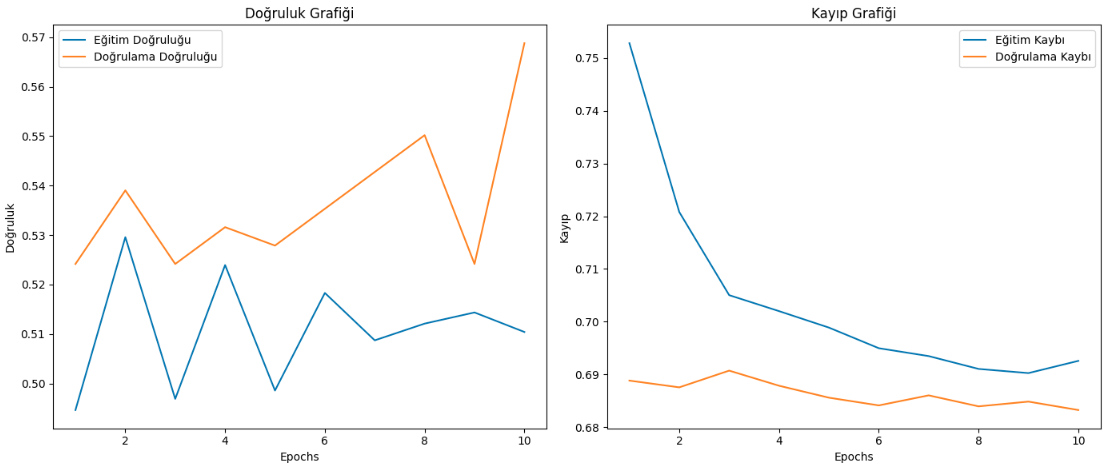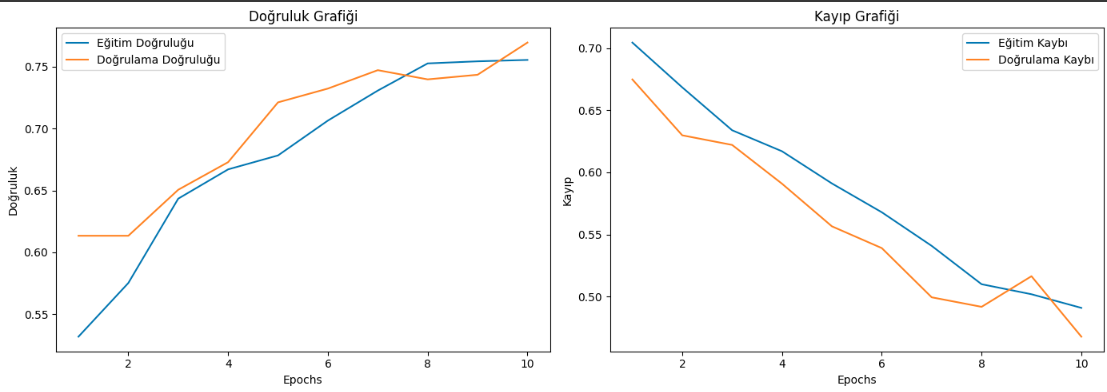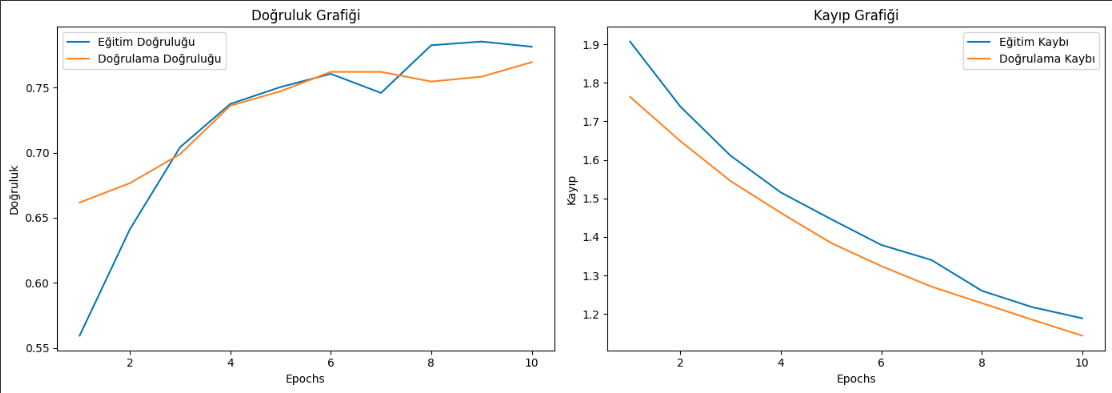

#### 30 epoch model karşılaştırması
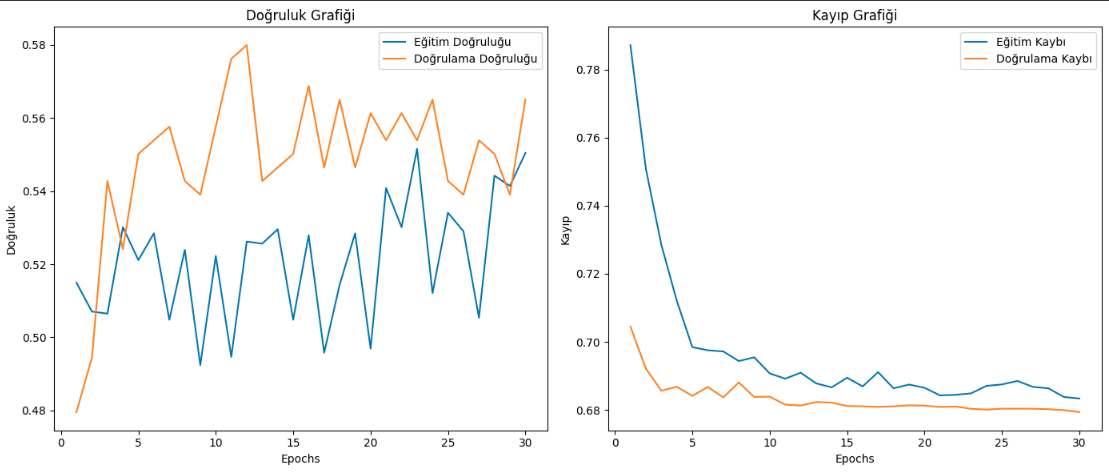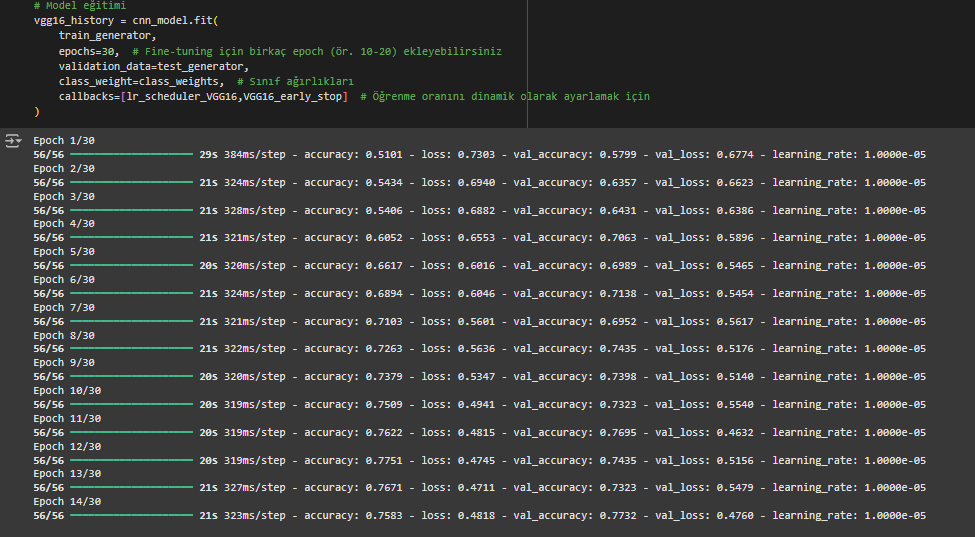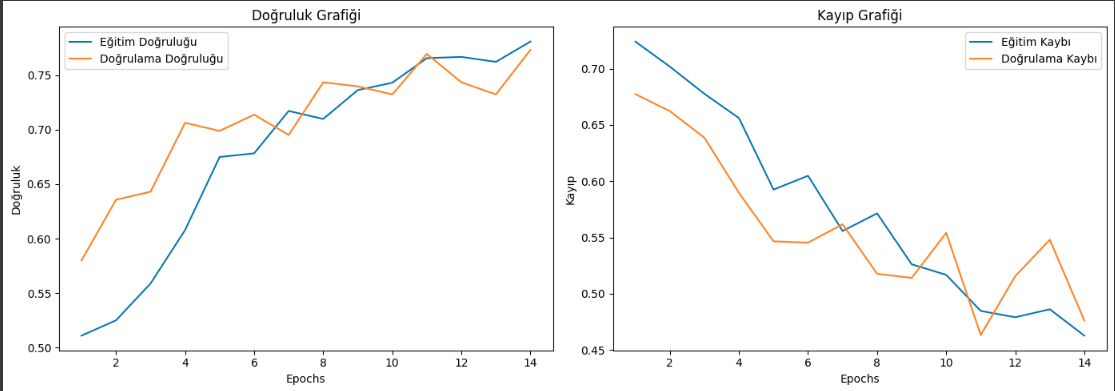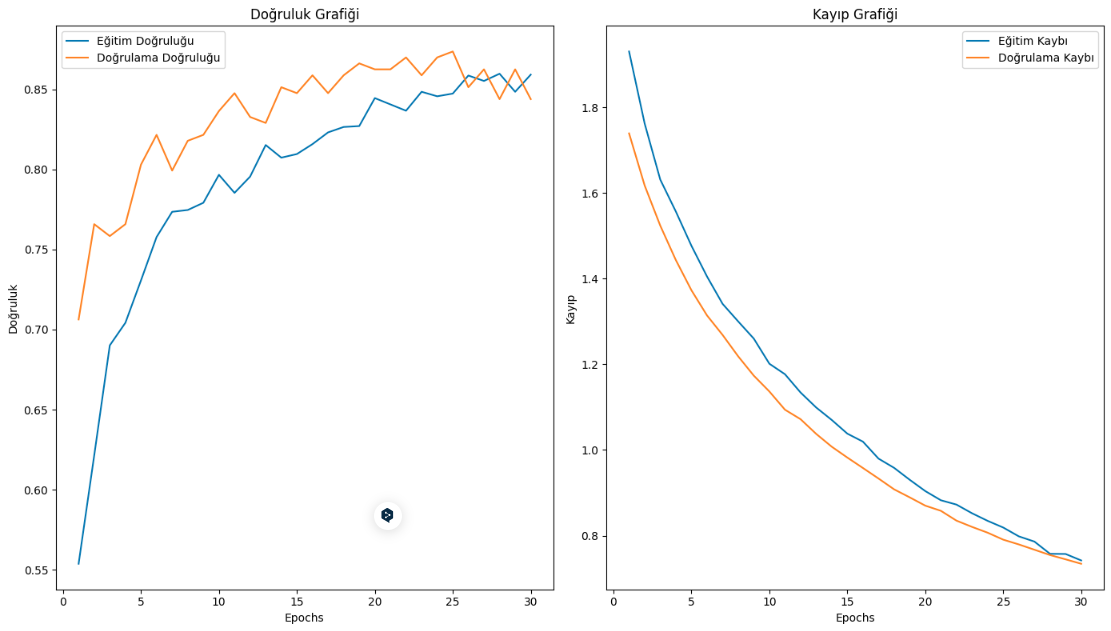

#### 50 epoch model karşılaştırması
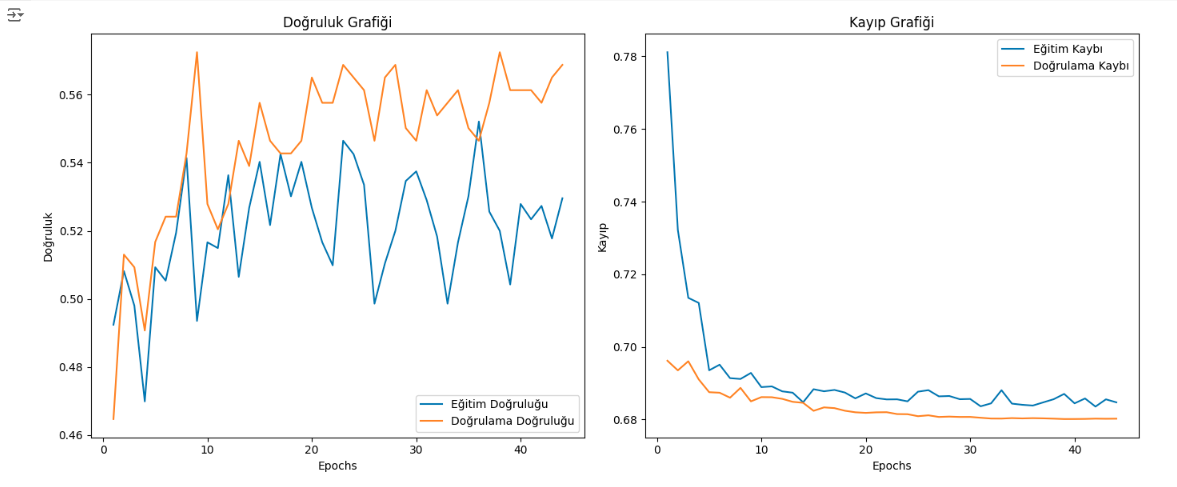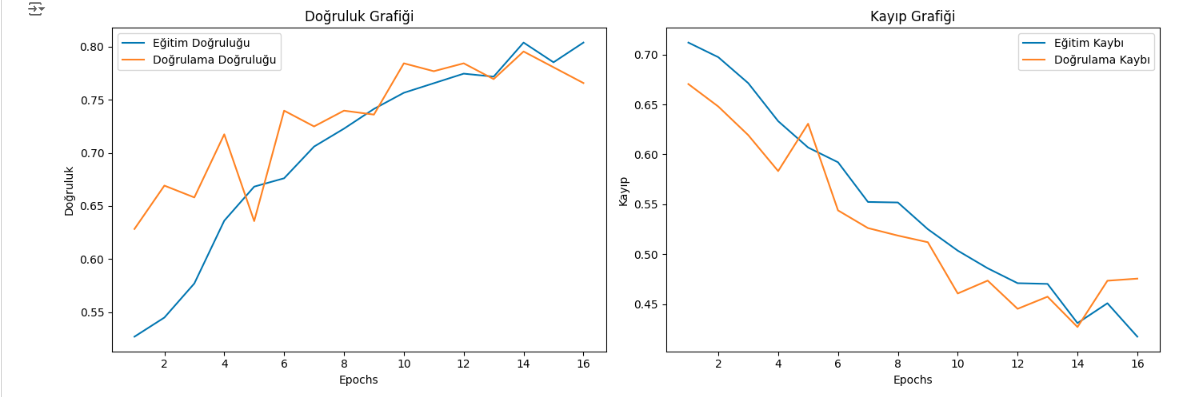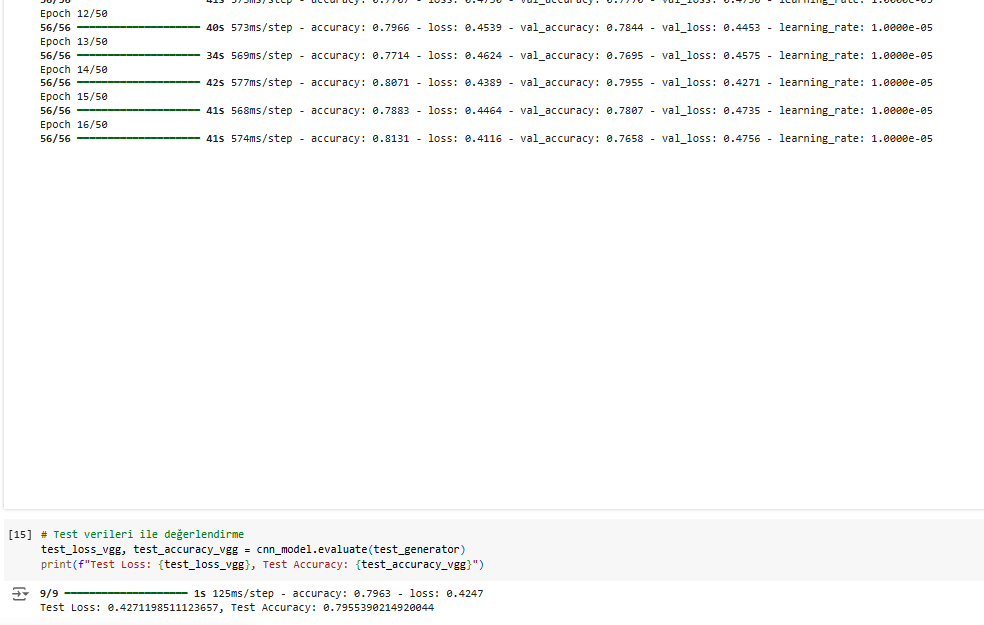


#Genel Karşılaştırma Tablosu

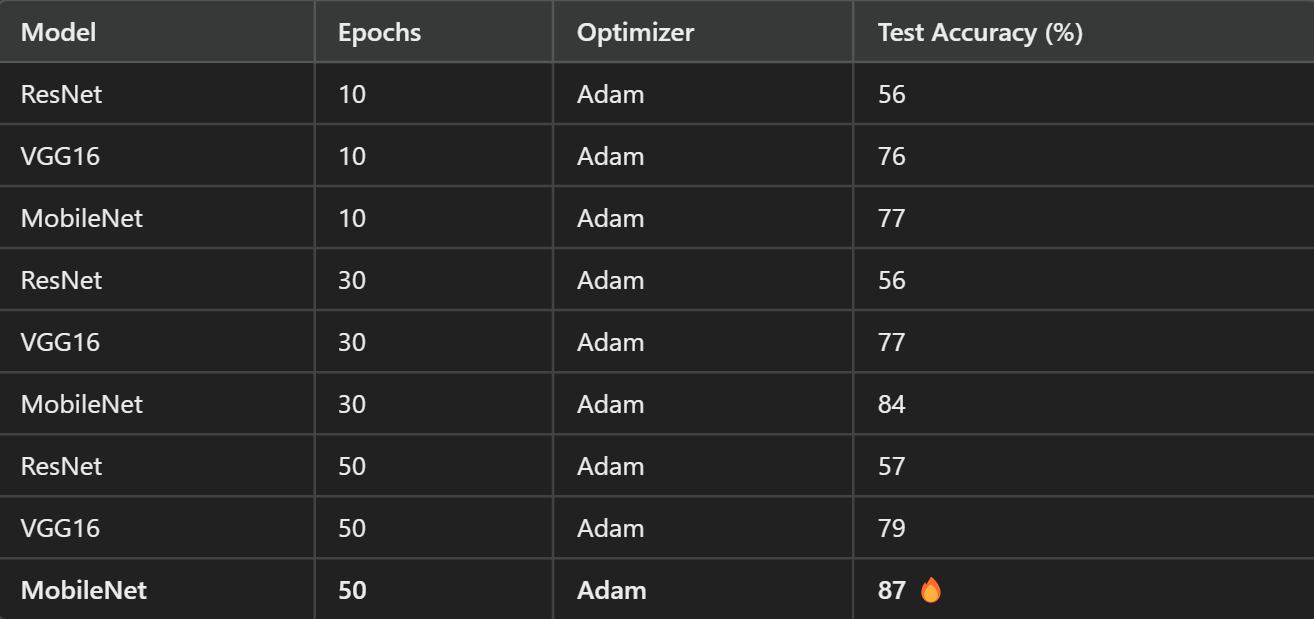